In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import gymnasium as gym

In [3]:
env = gym.make("CartPole-v1",
            render_mode='rgb_array')

c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


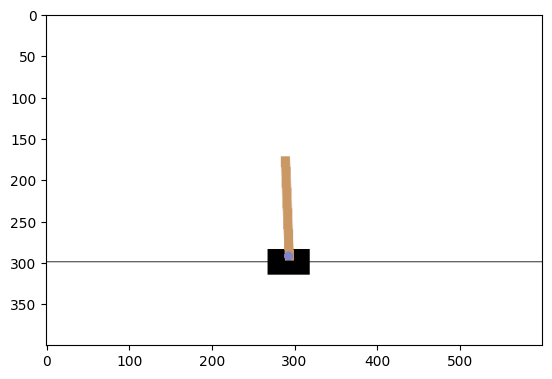

In [4]:
obs,info = env.reset()
img = env.render()
plt.imshow(img)

In [5]:
print(obs)
info

[-0.04850656  0.01312142 -0.03891446 -0.02361571]


{}

In [6]:
class DQN(nn.Module):

    def __init__(self,n_states,n_actions):
        super().__init__()
        self.n_states = n_states
        self.n_actions = n_actions

        self.network = nn.Sequential(
            nn.Linear(self.n_states,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,self.n_actions)
        )
        

    def forward(self,states):
         return self.network(states)

    
            
            

In [7]:

class DQNAgent:

    def __init__(self,env,n_states,n_actions,n_episodes,gamma=0.99,epsilon=1,epsilon_dec=0.9995,epsilon_min=0.01):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.n_episodes = n_episodes
        self.n_actions = n_actions
        self.n_states = n_states
        self.epsilon_dec = epsilon_dec
        self.epsilon_min = epsilon_min

        self.total_steps = 0
        self.lr = 1e-3
        self.memory = deque(maxlen = 20000)
        self.target_update_steps = 500
        self.batch_size = 64
        self.steps = 0
        self.loss_value = 0

        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.online_net = DQN(n_states,n_actions)
        self.online_net.to(self.device)
        self.target_net = DQN(n_states,n_actions)
        self.target_net.to(self.device)

        self.optimizer = Adam(self.online_net.parameters(),lr=self.lr)
        self.loss = nn.SmoothL1Loss() 
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()



    def select_action(self,state):

        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:

            state = torch.tensor(state).unsqueeze(0).to(self.device)

            with torch.no_grad():
                q_vals = self.online_net(state)
            return torch.argmax(q_vals).item()


    def replay_buffer(self):
        if len(self.memory) < self.batch_size:
            return
        if self.total_steps % 8 != 0:
            return

        
        batch_data = random.sample(self.memory, self.batch_size)
        states ,actions, rewards, next_states ,done = zip(*batch_data)
        
        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1).to(self.device)

        currentQ = self.online_net(states).gather(1,actions)

        with torch.no_grad():
            nextQ = self.target_net(next_states).max(1,keepdim=True)[0]
            targetQ = rewards + self.gamma * nextQ * (1-done)

        
        loss = self.loss(currentQ,targetQ)
        self.loss_value += loss.item()
        self.optimizer.zero_grad()
        loss.backward() #backprop
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.steps += 1

        if self.steps % self.target_update_steps == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        
    # reward clipping pole ko angle ko basis ma
    def step(self,action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        theta = obs[2]

        reward -= 2.0 * abs(theta)    #soft angle penalty
        return obs, reward, terminated, truncated , info
        

        
    def train(self):
        
        for episode in range(self.n_episodes):
            state,info = env.reset()
            state = state
            total_reward = 0
            done = False

            
            while not done:
                
                action = self.select_action(state)
                next_state, reward, ternimated, truncated, _ = self.step(action)

                done = ternimated or truncated

                total_reward += reward

                self.memory.append((state,action,reward,next_state,done))

                state = next_state

                self.total_steps += 1
                
                self.replay_buffer()

            if episode%10 == 0:
                self.epino_forplot.append(episode)
                avg_reward = np.mean(self.all_rewards[-10:])
                self.reward_per_10epi.append(avg_reward)


            self.epsilon = max(self.epsilon_min,self.epsilon*self.epsilon_dec)
            self.all_rewards.append(total_reward)

                
            if episode%50 ==0:
                print(f"Episode {episode}, Reward {np.mean(self.all_rewards[-50:])}, Epsilon {self.epsilon:.4f}")
        
        
    def plot(self):
        plt.plot(self.epino_forplot, self.reward_per_10epi)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.title("DQN Training Progress")
        plt.show()


            
    


In [8]:
Agent = DQNAgent(env,4,2,2500)

In [9]:
Agent.train()

c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Ashutosh Thapa\AppData\Local\Temp\ipykernel_10220\682398601.py:62: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.tensor(states, dtype=torch.float32).to(self.device)


Episode 0, Reward 42.98612976074219, Epsilon 0.9995
Episode 50, Reward 19.18509292602539, Epsilon 0.9748
Episode 100, Reward 18.847341537475586, Epsilon 0.9507
Episode 150, Reward 19.820886611938477, Epsilon 0.9273
Episode 200, Reward 17.02715492248535, Epsilon 0.9044
Episode 250, Reward 20.761436462402344, Epsilon 0.8820
Episode 300, Reward 20.432920455932617, Epsilon 0.8602
Episode 350, Reward 17.932842254638672, Epsilon 0.8390
Episode 400, Reward 26.500123977661133, Epsilon 0.8183
Episode 450, Reward 28.838533401489258, Epsilon 0.7981
Episode 500, Reward 24.917238235473633, Epsilon 0.7784
Episode 550, Reward 30.835376739501953, Epsilon 0.7591
Episode 600, Reward 31.546743392944336, Epsilon 0.7404
Episode 650, Reward 40.43299865722656, Epsilon 0.7221
Episode 700, Reward 41.75685119628906, Epsilon 0.7043
Episode 750, Reward 44.43392562866211, Epsilon 0.6869
Episode 800, Reward 49.113975524902344, Epsilon 0.6699
Episode 850, Reward 51.03583526611328, Epsilon 0.6534
Episode 900, Reward 

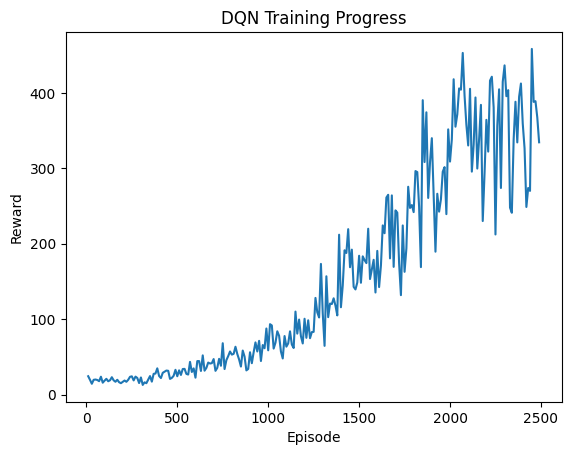

In [10]:
Agent.plot()

In [11]:
torch.save(Agent.online_net.state_dict(), "DQN-PyTorch-Online_net.pth")

In [12]:
env = gym.make("CartPole-v1",render_mode = "human")
agent = DQNAgent(env,4,2,2500)
agent.online_net.load_state_dict(torch.load("DQN-PyTorch-Online_net.pth"))
agent.online_net.eval()

for i in range (3):
    state,_ = env.reset()
    done = False
    total_reward = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    while not done:
        with torch.no_grad():
            state = torch.tensor(state).unsqueeze(0).to(device)
            action = torch.argmax(agent.online_net(state)).item()
        next_state, reward, term, trunc, _ = env.step(action)
        total_reward += reward
        done = term or trunc
        state = next_state
    
    print(f'Total Reward This Episode: {total_reward}')
env.close()
            

Total Reward This Episode: 500.0
Total Reward This Episode: 500.0
Total Reward This Episode: 500.0
